# Phase 3 / Day 1 — Sprint 1 Planning & Neural Network Architecture 

*Phase 3 of the internship runs across 4 one-week sprints.*


## Sprint Planning

#### **Sprint 1 Plan**

**Focus:** Deep Learning Intro
**Sprint Goal:** Establish a robust classical baseline model, then build, tune, and evaluate a Keras Sequential neural network to beat the baseline.

| Event | Description |
|---|---|
| Sprint Planning - Day 1 | Confirm the Sprint 1 goal from Week 5, select backlog tasks, and commit the sprint goal. |
| Daily Standup | 3-munite update about what was completed, what is next, any issues. |
| Mentor Code & Notebook Review - Day 3 | Confirm the Sprint 1 goal from Week 5, select backlog tasks, and commit the sprint goal. |
| Sprint Review - Day 5 | Demo completed stages/results. Incomplete tasks move to Sprint 2. |
| Sprint Retrospective - Day 5 | Sprint 1 wrap-up and one specific action for Sprint 2. |



#### **Sprint 1 Backlog**

| Item | Tasks |
|---|---|
| Item 1 | Dataset preperation, EDA, baseline model training, opening a full draft pull request |
| Item 2 | Activation function plotting, output activation and loss function justification, and manual forward-pass coputation |
| Item 3 | Documentation of the 4 step training loop, learning rate experiments, mid-sprint Mentor Code & Notebook Review |
| Item 4 | Building and training Keras Sequential model, plotting loss curves, and evaluating against the baseline |
| Item 5 | Systematic hyperparameter tuning, implementing EarlyStopping/ModelCheckpoint callbacks, merging the pull reques, and closing with the Sprint review & Retrospective |


#### **Definition of Done (DoD) & Acceptance Criteria**

- [x] Notebook runs end-to-end without errors.
- [x] All code commited to GitHub via feature branches.
- [x] Mid-sprint mentor feedback is addressed.
- [x] Metrics are logged in a comparison table and the neural network beats the baseline.
- [x] The pull request is merged after mentor approval.
- [x] Written Sprint Retrospective is completes with one concrete action item for Sprint 2.

## Brief EDA & Dataset Preperation

*The same dataset and from the Cardiac Patient Monitoring System Project is used, and a snippet of the project's EDA is used to complete today's tasks.*

In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_curve

In [2]:
df = pd.read_csv("heart_2020_cleaned.csv")
df

,HeartDisease,BMI,Smoking,AlcoholDrinking,Stroke,PhysicalHealth,MentalHealth,DiffWalking,Sex,AgeCategory,Race,Diabetic,PhysicalActivity,GenHealth,SleepTime,Asthma,KidneyDisease,SkinCancer
0,No,16.60,Yes,No,No,3.0,30.0,No,Female,55-59,White,Yes,Yes,Very good,5.0,Yes,No,Yes
1,No,20.34,No,No,Yes,0.0,0.0,No,Female,80 or older,White,No,Yes,Very good,7.0,No,No,No
2,No,26.58,Yes,No,No,20.0,30.0,No,Male,65-69,White,Yes,Yes,Fair,8.0,Yes,No,No
3,No,24.21,No,No,No,0.0,0.0,No,Female,75-79,White,No,No,Good,6.0,No,No,Yes
4,No,23.71,No,No,No,28.0,0.0,Yes,Female,40-44,White,No,Yes,Very good,8.0,No,No,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
319790,Yes,27.41,Yes,No,No,7.0,0.0,Yes,Male,60-64,Hispanic,Yes,No,Fair,6.0,Yes,No,No
319791,No,29.84,Yes,No,No,0.0,0.0,No,Male,35-39,Hispanic,No,Yes,Very good,5.0,Yes,No,No
319792,No,24.24,No,No,No,0.0,0.0,No,Female,45-49,Hispanic,No,Yes,Good,6.0,No,No,No
319793,No,32.81,No,No,No,0.0,0.0,No,Female,25-29,Hispanic,No,No,Good,12.0,No,No,No


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 319795 entries, 0 to 319794
Data columns (total 18 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   HeartDisease      319795 non-null  object 
 1   BMI               319795 non-null  float64
 2   Smoking           319795 non-null  object 
 3   AlcoholDrinking   319795 non-null  object 
 4   Stroke            319795 non-null  object 
 5   PhysicalHealth    319795 non-null  float64
 6   MentalHealth      319795 non-null  float64
 7   DiffWalking       319795 non-null  object 
 8   Sex               319795 non-null  object 
 9   AgeCategory       319795 non-null  object 
 10  Race              319795 non-null  object 
 11  Diabetic          319795 non-null  object 
 12  PhysicalActivity  319795 non-null  object 
 13  GenHealth         319795 non-null  object 
 14  SleepTime         319795 non-null  float64
 15  Asthma            319795 non-null  object 
 16  KidneyDisease     31

In [4]:
df.head()

,HeartDisease,BMI,Smoking,AlcoholDrinking,Stroke,PhysicalHealth,MentalHealth,DiffWalking,Sex,AgeCategory,Race,Diabetic,PhysicalActivity,GenHealth,SleepTime,Asthma,KidneyDisease,SkinCancer
0,No,16.60,Yes,No,No,3.0,30.0,No,Female,55-59,White,Yes,Yes,Very good,5.0,Yes,No,Yes
1,No,20.34,No,No,Yes,0.0,0.0,No,Female,80 or older,White,No,Yes,Very good,7.0,No,No,No
2,No,26.58,Yes,No,No,20.0,30.0,No,Male,65-69,White,Yes,Yes,Fair,8.0,Yes,No,No
3,No,24.21,No,No,No,0.0,0.0,No,Female,75-79,White,No,No,Good,6.0,No,No,Yes
4,No,23.71,No,No,No,28.0,0.0,Yes,Female,40-44,White,No,Yes,Very good,8.0,No,No,No


In [5]:
missing = df.isnull().sum()
missing_prcnt = (missing/len(df))*100
missing_df = pd.DataFrame({"Missing Values": missing, "Percentage":missing_prcnt})
missing_df = missing_df[missing_df["Missing Values"]>0]
missing_df

,Missing Values,Percentage


In [6]:
df.duplicated().sum()

np.int64(18078)

In [7]:
df.columns

Index(['HeartDisease', 'BMI', 'Smoking', 'AlcoholDrinking', 'Stroke',
       'PhysicalHealth', 'MentalHealth', 'DiffWalking', 'Sex', 'AgeCategory',
       'Race', 'Diabetic', 'PhysicalActivity', 'GenHealth', 'SleepTime',
       'Asthma', 'KidneyDisease', 'SkinCancer'],
      dtype='object')

In [8]:
df.describe()

,BMI,PhysicalHealth,MentalHealth,SleepTime
count,319795.000000,319795.00000,319795.000000,319795.000000
mean,28.325399,3.37171,3.898366,7.097075
std,6.356100,7.95085,7.955235,1.436007
min,12.020000,0.00000,0.000000,1.000000
25%,24.030000,0.00000,0.000000,6.000000
50%,27.340000,0.00000,0.000000,7.000000
75%,31.420000,2.00000,3.000000,8.000000
max,94.850000,30.00000,30.000000,24.000000


In [9]:
#grouping categorical columns
categ_cols = df.select_dtypes(include=['object', 'bool']).columns.tolist() 
low_cardinality_numeric = [col for col in df.select_dtypes(include=['int64','float64']).columns 
                           if df[col].nunique() <= 5]
categ_cols = categ_cols + low_cardinality_numeric

#grouping numerical columns
numeric_cols = [col for col in df.select_dtypes(include=['int64','float64']).columns 
                           if df[col].nunique() > 5]


print("Number of unique values per column:")
for col in categ_cols:
    print(col, df[col].nunique())

Number of unique values per column:
HeartDisease 2
Smoking 2
AlcoholDrinking 2
Stroke 2
DiffWalking 2
Sex 2
AgeCategory 13
Race 6
Diabetic 4
PhysicalActivity 2
GenHealth 5
Asthma 2
KidneyDisease 2
SkinCancer 2


In [10]:
numeric_cols

['BMI', 'PhysicalHealth', 'MentalHealth', 'SleepTime']

In [11]:
for col in categ_cols:
    print(df[col].value_counts(normalize=True)*100)

HeartDisease
No     91.440454
Yes     8.559546
Name: proportion, dtype: float64
Smoking
No     58.752326
Yes    41.247674
Name: proportion, dtype: float64
AlcoholDrinking
No     93.190325
Yes     6.809675
Name: proportion, dtype: float64
Stroke
No     96.22602
Yes     3.77398
Name: proportion, dtype: float64
DiffWalking
No     86.112979
Yes    13.887021
Name: proportion, dtype: float64
Sex
Female    52.472678
Male      47.527322
Name: proportion, dtype: float64
AgeCategory
65-69          10.679029
60-64          10.533623
70-74           9.714036
55-59           9.305024
50-54           7.936960
80 or older     7.552651
45-49           6.814053
75-79           6.717428
18-24           6.586720
40-44           6.568583
35-39           6.425992
30-34           5.864069
25-29           5.301834
Name: proportion, dtype: float64
Race
White                             76.677872
Hispanic                           8.582373
Black                              7.173033
Other                      

In [12]:
df.shape

(319795, 18)

#### EDA Observations

**Missing values & duplicates**
There are no missing values, however, those values are self-reported survey responses rather than clinical measurements. 18,078 duplicate rows were found which is expected with a few numerical features, those duplicated rows were removed reducing the rows to 301,717.

#### Descriptive statistics takeaways

**BMI:** mean = 28.3 / std=6.35 *in the overweight range*. The max = 94.8 is an extreme value *outlier*.
**PhysicalHealth / MentalHealth:** strongly 0 inflated which causes a right skew
**SleepTime:** arounf 7 hours which is fairly centered, but the max being 24 hours is an indicator of self-reported data.

#### Categorical Distribution takeaways

- **Target imbalance:** `HeartDisease` is extrmely imbalanced with only 8.5% of the records having heart diseas. Class weighting/resampling will be required for medl training.
- Other risk factors are also imbalanced; ` Stroke`, `KidneyDisease`, `AlcholholDrinking`.
- `Race` is heavily skewed towards *White* with all othe rgroups forming minorities.
- `AgeCategory` is evenly distributed.

### Dataset Cleaning

In [13]:
#dropping duplicates
df = df.drop_duplicates().reset_index(drop=True)
df.duplicated().sum()

np.int64(0)

In [14]:
# Traget encoding
df["HeartDisease"] = df["HeartDisease"].map({"Yes":1, "No":0})

In [15]:
#seperating the target
x = df.drop(columns=["HeartDisease"])
y = df["HeartDisease"]

#splitting 80/20 the data
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size= 0.2, stratify=y, random_state=42)

In [16]:
#basic categorical features encoding
x_train = pd.get_dummies(x_train, drop_first=True)
x_test = pd.get_dummies(x_test, drop_first=True)
x_test = x_test.reindex(columns=x_train.columns, fill_value=0)

In [21]:
#numerical features scaling

numeric_to_Scale = ['BMI', 'PhysicalHealth', 'MentalHealth', 'SleepTime']
scaler = StandardScaler()
x_train[numeric_to_Scale] = scaler.fit_transform(x_train[numeric_to_Scale])
x_test[numeric_to_Scale] = scaler.transform(x_test[numeric_to_Scale])
df.shape

(301717, 18)

## Training the Baseline Model

In [18]:
lreg = LogisticRegression(max_iter=1000, class_weight="balanced")
lreg.fit(x_train, y_train)
lreg_prob = lreg.predict_proba(x_test)[:,1]
lreg_pred =lreg.predict(x_test)

print("Baseline ROC-AUC:", roc_auc_score(y_test, lreg_prob))
print("Baseline Accuracy:", roc_auc_score(y_test, lreg_pred))
print(classification_report(y_test, lreg_pred))


Baseline ROC-AUC: 0.8320213732973369
Baseline Accuracy: 0.7568124099779684
              precision    recall  f1-score   support

           0       0.97      0.74      0.84     54892
           1       0.23      0.78      0.35      5452

    accuracy                           0.74     60344
   macro avg       0.60      0.76      0.59     60344
weighted avg       0.90      0.74      0.79     60344



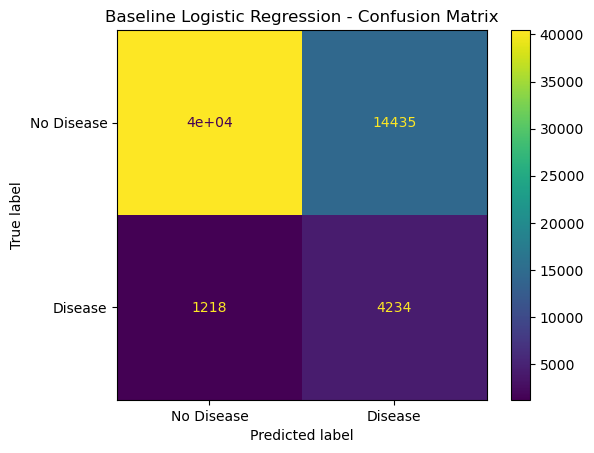

In [19]:
cfmx_lr = confusion_matrix(y_test, lreg_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cfmx_lr, display_labels=["No Disease", "Disease"])
disp.plot(cmap='viridis')
plt.title("Baseline Logistic Regression - Confusion Matrix")
plt.show()

| Label | Count |
|---|---|
| True Negatives | 40,000 |
| False Positives | 14,435 |
| False Negatives | 1,218 |
| True Positives | 4,234 |

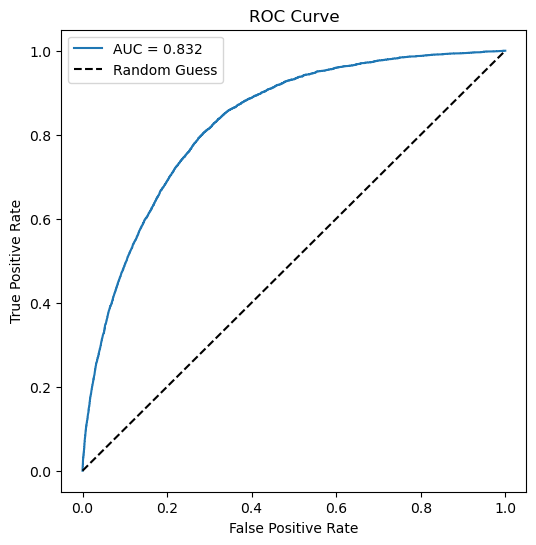

In [20]:
false_pos_rate, true_pos_rate, thresholds = roc_curve(y_test, lreg_prob)
auc = roc_auc_score(y_test, lreg_prob)

plt.figure(figsize=(6,6))
plt.plot(false_pos_rate, true_pos_rate, label=f"AUC = {auc:.3f}")
plt.plot([0,1], [0,1], "k--", label="Random Guess")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

#### *Results & Observations*

**Confusion Matrix:** The model *correctly classifies 40,000 True negative cases* which is a high performance indicator. However, *14,435 healthy patients were incorreclty flagged as at risk*, while *4234 patients with heart disease were correctly identified*. *1,218 heart disease patients were incorrectly classified as healthy* - higher medical concern.

**Recall:** The model correctly flags 74% of the overall healthy patients and 78% of at risk patients. 

**ROC-AUC:** The AUC score - 0.832 - indicates that logistic regression model has good ability to distinguish between the two classes.

***Main Takeaway:*** The model provides a reasonable baseline with good overall detecting ability but it produces a considerably high number of False Positives. For further improvement, hyperparameter tuning can be explored to improve theses proportions.